In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.stats import chi2_contingency
import queue
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

In [2]:
def preprocess_data(df):
    df.drop(columns=["Unnamed: 0.1", "Unnamed: 0", "sessionId", "time", "th1", "th1_value", 'th2', 'th2_value', 'th3', 'th3_value', 'wudate', 'lon', 'lat'], inplace=True)
    df["fusion_model_prediction"] = df["fusion_model_prediction"].replace("NO PREDICTION (0.0000)", None)
    df["Call_Presence"] = df["fusion_model_prediction"].notnull().astype(int)

    print("Aviary Data:")
    print(df.head())

    return df

In [3]:
# Load and preprocess the data
selected_1_avriary_path = "metadata_aviaries/fl_zoo_eindhoven_20250308_meta.xlsx"
selected_2_avriary_path = "metadata_aviaries/fl_zoo_eindhoven_20250426_meta.xlsx"

if not os.path.exists("processed_data"):
    os.makedirs("processed_data")
    df_1 = pd.read_excel(selected_1_avriary_path)
    df_2 = pd.read_excel(selected_2_avriary_path)

    df_1 = preprocess_data(df_1)
    df_2 = preprocess_data(df_2)

    
    df_1.to_pickle("processed_data/aviary_1_data.pkl")
    df_2.to_pickle("processed_data/aviary_2_data.pkl")
else:
    df_1 = pd.read_pickle("processed_data/aviary_1_data.pkl")
    df_2 = pd.read_pickle("processed_data/aviary_2_data.pkl")


In [ ]:
# Create new column final prediciton using bidnet prediction
"""
def clean_prediction(df):
    df["birdnet_prediction"] = df["birdnet_prediction"].replace("NO PREDICTION (0.0000)", None)
    df["Final prediction"] = None
    
    for idx, row in df.iterrows():

        subset = str(row["birdnet_prediction"]).split(" ")
        try:
            if subset[0] == "nan":
                row["Final prediction"] = None
                continue

            pred_score = subset[-1]
            if float(pred_score[1:-1]) < 0.15:
                row["Final prediction"] = None
                continue
            tmp_pred = ""
            for string in subset[:-1]:
                tmp_pred += string + " "

            df.loc[idx, "Final prediction"] = tmp_pred

        except Exception as error:
            print(f"Error processing row {idx}: {error}")
            print(subset)
    
    return df

#df_1 = clean_prediction(df_1)
#df_2 = clean_prediction(df_2)

#df_1["Final prediction"].value_counts()

"""


Final prediction
Phoenicopterus roseus Greater Flamingo           36519
Pica pica Eurasian Magpie                         3442
Ciconia ciconia White Stork                       3298
Passer domesticus House Sparrow                   2710
Corvus monedula Eurasian Jackdaw                  1840
Gallinula chloropus Eurasian Moorhen              1793
Egretta garzetta Little Egret                      744
Columba palumbus Common Wood Pigeon                658
Columba livia Rock Pigeon                          537
Branta canadensis Canada Goose                     428
Geronticus eremita Northern Bald Ibis              390
Corvus corone Carrion Crow                         277
Streptopelia decaocto Eurasian Collared Dove       187
Ciconia nigra Black Stork                          149
Mareca sibilatrix Chiloe Wigeon                    117
Fulica atra Eurasian Coot                           84
Phylloscopus collybita Common Chiffchaff            19
Fringilla coelebs Eurasian Chaffinch            

In [43]:
# Genrate final prediction using fusion model prediction
def clean_prediction(df):
    df["Final prediction"] = None
    
    for idx, row in df.iterrows():
        lines = str(row["fusion_model_prediction"]).split("\n")
        for line in lines:
            subset = line.split(" ")
            try:
                if subset[0] == "nan":
                    row["Final prediction"] = None
                    continue

                pred_score = subset[-1]
                if float(pred_score[1:-1]) < 0.15:
                    row["Final prediction"] = None
                    continue
                tmp_pred = ""
                for string in subset[:-1]:
                    tmp_pred += string + " "

                if df.loc[idx, "Final prediction"] is not None:
                    df.loc[idx, "Final prediction"] += ", " + tmp_pred
                else:
                    df.loc[idx, "Final prediction"] = tmp_pred

            except Exception as error:
                print(f"Error processing row {idx}: {error}")
                print(subset)
    
    return df

df_1 = clean_prediction(df_1)
df_1["Final prediction"].value_counts()

Final prediction
Phoenicopterus roseus Greater Flamingo                                                                    23933
Phoenicopterus roseus Greater Flamingo , Passer domesticus House Sparrow                                   5260
Pica pica Eurasian Magpie                                                                                  2894
Passer domesticus House Sparrow                                                                            2734
Ciconia ciconia White Stork                                                                                1863
                                                                                                          ...  
Corvus monedula Eurasian Jackdaw , Ciconia ciconia White Stork , Egretta garzetta Little Egret                1
Passer domesticus House Sparrow , Egretta garzetta Little Egret , Pica pica Eurasian Magpie                   1
Passer domesticus House Sparrow , Columba livia Rock Pigeon , Geronticus eremita Northe

In [44]:
df_1[df_1["Final prediction"].notnull()]["Final prediction"]

13                 Phoenicopterus roseus Greater Flamingo 
16                 Phoenicopterus roseus Greater Flamingo 
23                 Phoenicopterus roseus Greater Flamingo 
24                 Phoenicopterus roseus Greater Flamingo 
25                 Phoenicopterus roseus Greater Flamingo 
                               ...                        
74410    Phoenicopterus roseus Greater Flamingo , Egret...
74412          Parus major Great Tit , Eurasian Chaffinch 
74415                     Passer domesticus House Sparrow 
74418                           Pica pica Eurasian Magpie 
74419                                    Common Blackbird 
Name: Final prediction, Length: 64876, dtype: object

In [45]:
counts = df_1["MIT_AST_label"].value_counts()
for e in counts.index:
    print(f"{e}: {counts[e]}")

Animal: 15776
Fowl: 11188
speech_removed: 8980
Honk: 7983
Quack: 6985
Bird: 5132
Vehicle: 2299
Duck: 2156
Crow: 1954
Oink: 1892
Frog: 1850
Throat clearing: 696
Roar: 604
Raindrop: 514
Squawk: 493
Music: 467
Chicken, rooster: 423
Owl: 420
Caw: 409
Engine: 383
Goose: 373
Bow-wow: 269
Vehicle horn, car horn, honking: 208
Bleat: 196
Hoot: 189
Howl: 188
Water: 167
Chirp, tweet: 155
Liquid: 145
Sheep: 121
Squeak: 119
Sawing: 110
Roaring cats (lions, tigers): 101
Dog: 94
Rub: 86
Bird vocalization, bird call, bird song: 83
Cattle, bovinae: 80
Train: 78
Cluck: 77
Rain: 68
Crowing, cock-a-doodle-doo: 64
Sound effect: 59
Domestic animals, pets: 56
Rain on surface: 46
Livestock, farm animals, working animals: 43
Rattle: 43
Whale vocalization: 41
Squeal: 29
Whistling: 28
Canidae, dogs, wolves: 27
Snort: 26
Bird flight, flapping wings: 24
Wood: 22
Moo: 21
Gurgling: 19
Clip-clop: 16
Gasp: 16
Cat: 15
Pant: 14
Snicker: 13
Turkey: 13
Stream: 12
Mechanisms: 12
Crowd: 10
Sneeze: 10
Boiling: 10
Thunderstor

In [39]:
for r in df_1['MIT_AST_label'].unique():
    print(r)

speech_removed
Whack, thwack
Fowl
Animal
Oink
Crowd
Honk
Rub
Sawing
Squeal
Vehicle
Chicken, rooster
Sound effect
Quack
Frog
Caw
Bird
Duck
Squawk
Crow
Music
Dog
Bleat
Bow-wow
Throat clearing
Crowing, cock-a-doodle-doo
Goose
Croak
Roar
Livestock, farm animals, working animals
Roaring cats (lions, tigers)
Wood
Snicker
Battle cry
Owl
Raindrop
Squeak
Liquid
Clip-clop
Sheep
Scrape
Snort
Domestic animals, pets
Whistling
Engine
Canidae, dogs, wolves
Howl
Water
Vehicle horn, car horn, honking
Pant
Crack
Rain
Foghorn
Gurgling
Rain on surface
Car
Train
Hoot
Heart sounds, heartbeat
Hum
Whale vocalization
Sneeze
Chink, clink
Moo
Cat
Gobble
Cattle, bovinae
Drip
Turkey
Boiling
Rattle
Stream
Clapping
Burping, eructation
Buzzer
Pour
Bird flight, flapping wings
Cluck
Chirp, tweet
Bird vocalization, bird call, bird song
Gargling
Slosh
Mechanisms
Neigh, whinny
Horse
Thunder
Toilet flush
Meow
Typing
Gasp
Medium engine (mid frequency)
Tick-tock
Typewriter
Applause
Clang
Toothbrush
Rumble
Siren
Throbbing
Whi

In [92]:
MIT_classes_of_interest = ["Crowd", "Civil defense siren", "Railroad car, train wagon", "Vehicle", "Motorcycle", "Thunderstorm", "Air horn, truck horn", 
                           "Grunt", "Engine starting", "Siren", "Medium engine (mid frequency)", "Thunder", "Train", "Car", "Vehicle horn, car horn, honking",
                           "Roaring cats (lions, tigers)", "Roar", "Dog"]
previous_event = None
call_dict = {}

df_1_subset = df_1[df_1["MIT_AST_label"].isin(MIT_classes_of_interest)]
MIT_key = "occurence over dataset"
for idx, row in df_1_subset.iterrows():
    key = MIT_key + "-" + str(row["MIT_AST_label"])
    if key not in call_dict:
        call_dict[key] = 0

    call_dict[key] += 1

for idx, row in df_1.iterrows():
    if row["Final prediction"] is None:
        continue 
    
    predictions = str(row["Final prediction"]).split(", ")
    current_event = row["MIT_AST_label"]
    
    if predictions != "None" and previous_event in MIT_classes_of_interest:
        for prediction in predictions:
            key = prediction + "-" + str(previous_event)
            if key not in call_dict:
                call_dict[key] = 0
            
            call_dict[key] += 1
    
    previous_event = current_event

print(call_dict)

{'occurence over dataset-Crowd': 10, 'occurence over dataset-Vehicle': 2299, 'occurence over dataset-Dog': 94, 'occurence over dataset-Roar': 604, 'occurence over dataset-Roaring cats (lions, tigers)': 101, 'occurence over dataset-Vehicle horn, car horn, honking': 208, 'occurence over dataset-Car': 9, 'occurence over dataset-Train': 78, 'occurence over dataset-Thunder': 8, 'occurence over dataset-Medium engine (mid frequency)': 2, 'occurence over dataset-Siren': 6, 'occurence over dataset-Engine starting': 1, 'occurence over dataset-Grunt': 3, 'occurence over dataset-Air horn, truck horn': 1, 'occurence over dataset-Motorcycle': 1, 'occurence over dataset-Thunderstorm': 10, 'occurence over dataset-Civil defense siren': 1, 'occurence over dataset-Railroad car, train wagon': 1, 'Phoenicopterus roseus Greater Flamingo -Crowd': 9, 'Phoenicopterus roseus Greater Flamingo -Vehicle': 744, 'Phoenicopterus roseus Greater Flamingo -Dog': 67, 'Pica pica Eurasian Magpie -Dog': 12, 'Fulica atra Eur

In [93]:
reaction_df = pd.DataFrame([
    {'species': k.rsplit('-', 1)[0], 'event': k.rsplit('-', 1)[1], 'count': v} 
    for k, v in call_dict.items()
])

species_totals = reaction_df.groupby('species')['count'].sum().sort_values(ascending=False)
print("Most reactive species:")
display(species_totals.head(10))

event_totals = reaction_df.groupby('event')['count'].sum().sort_values(ascending=False)
print("\nMost reactive events:")
display(event_totals.head(10))

Most reactive species:


species
occurence over dataset                     3437
Phoenicopterus roseus Greater Flamingo     1127
Ciconia ciconia White Stork                 707
Gallinula chloropus Eurasian Moorhen        476
Eurasian Collared Dove                      393
Passer domesticus House Sparrow             369
Columba palumbus Common Wood Pigeon         283
Columba livia Rock Pigeon                   276
Pica pica Eurasian Magpie                   256
Fulica atra Eurasian Coot                   204
Name: count, dtype: int64


Most reactive events:


event
Vehicle                            5596
Roar                               1772
Vehicle horn, car horn, honking     525
Roaring cats (lions, tigers)        296
Dog                                 251
Train                               192
Car                                  30
Thunderstorm                         28
Crowd                                23
Siren                                19
Name: count, dtype: int64

In [94]:
# Make pivot table comparing species and events rate 
reaction_df = reaction_df.drop(reaction_df[reaction_df['count'] < 5].index) 

pivot_table = reaction_df.pivot_table(index='species', columns='event', values='count', fill_value=0)
pivot_table["Total"] = pivot_table.sum(axis=1)
pivot_table = pivot_table.sort_values(by="Total", ascending=False)

display(pivot_table)

event,Car,Crowd,Dog,Roar,"Roaring cats (lions, tigers)",Siren,Thunder,Thunderstorm,Train,Vehicle,"Vehicle horn, car horn, honking",Total
species,,,,,,,,,,,,
occurence over dataset,9.0,10.0,94.0,604.0,101.0,6.0,8.0,10.0,78.0,2299.0,208.0,3427.0
Phoenicopterus roseus Greater Flamingo,0.0,9.0,67.0,129.0,17.0,0.0,0.0,5.0,25.0,744.0,122.0,1118.0
Ciconia ciconia White Stork,0.0,0.0,7.0,44.0,15.0,0.0,0.0,0.0,0.0,631.0,8.0,705.0
Gallinula chloropus Eurasian Moorhen,0.0,0.0,6.0,99.0,9.0,0.0,0.0,0.0,5.0,315.0,37.0,471.0
Eurasian Collared Dove,0.0,0.0,0.0,62.0,15.0,0.0,0.0,0.0,15.0,287.0,6.0,385.0
Passer domesticus House Sparrow,0.0,0.0,32.0,36.0,53.0,0.0,0.0,0.0,10.0,214.0,16.0,361.0
Columba palumbus Common Wood Pigeon,0.0,0.0,0.0,172.0,9.0,0.0,0.0,0.0,8.0,87.0,0.0,276.0
Columba livia Rock Pigeon,5.0,0.0,0.0,229.0,19.0,0.0,0.0,0.0,0.0,20.0,0.0,273.0
Pica pica Eurasian Magpie,0.0,0.0,12.0,33.0,14.0,0.0,0.0,0.0,11.0,172.0,9.0,251.0


In [100]:
# Combine non natives birds into one category
natives = ["occurence over dataset", "Black stork", "Chiloe wigeon", "Goliath heron", "Greater flamingo", "Little egret", "Northern bald ibis", "Pink-backed pelican", "Scarlet ibis", "Straw-necked ibis"]
native_reaction_df = reaction_df.copy()

for idx, row in reaction_df.iterrows():
    found = False
    found_specie = None
    specie = row["species"]
    for native in natives:
        if specie.lower().find(native.lower()) != -1:
            found = True
            found_specie = native
            break

    if not found:
        native_reaction_df.loc[idx, "species"] = "other bird"
    else:
        native_reaction_df.loc[idx, "species"] = found_specie

native_reaction_df = native_reaction_df.groupby(['species', 'event']).agg({'count': 'sum'}).reset_index()
print(native_reaction_df["species"].value_counts())
display(native_reaction_df.head(20))



species
occurence over dataset    11
Greater flamingo           8
other bird                 7
Little egret               4
Northern bald ibis         3
Black stork                1
Chiloe wigeon              1
Name: count, dtype: int64


,species,event,count
0,Black stork,Roar,7
1,Chiloe wigeon,Roar,61
2,Greater flamingo,Crowd,9
3,Greater flamingo,Dog,67
4,Greater flamingo,Roar,129
5,Greater flamingo,"Roaring cats (lions, tigers)",17
6,Greater flamingo,Thunderstorm,5
7,Greater flamingo,Train,25
8,Greater flamingo,Vehicle,765
9,Greater flamingo,"Vehicle horn, car horn, honking",132


In [101]:
native_pivot = native_reaction_df.pivot_table(index='species', columns='event', values='count', fill_value=0)
native_pivot["Total"] = native_pivot.sum(axis=1)
native_pivot = native_pivot.sort_values(by="Total", ascending=False)

df_1["MIT_AST_label"].value_counts()

display(native_pivot)

event,Car,Crowd,Dog,Roar,"Roaring cats (lions, tigers)",Siren,Thunder,Thunderstorm,Train,Vehicle,"Vehicle horn, car horn, honking",Total
species,,,,,,,,,,,,
other bird,5.0,0.0,63.0,792.0,152.0,0.0,0.0,0.0,70.0,2397.0,140.0,3619.0
occurence over dataset,9.0,10.0,94.0,604.0,101.0,6.0,8.0,10.0,78.0,2299.0,208.0,3427.0
Greater flamingo,0.0,9.0,67.0,129.0,17.0,0.0,0.0,5.0,25.0,765.0,132.0,1149.0
Little egret,0.0,0.0,8.0,44.0,0.0,0.0,0.0,0.0,0.0,96.0,30.0,178.0
Northern bald ibis,0.0,0.0,0.0,123.0,9.0,0.0,0.0,0.0,0.0,19.0,0.0,151.0
Chiloe wigeon,0.0,0.0,0.0,61.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,61.0
Black stork,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0


## Do something similar but looking at bird vocal interaction

In [10]:
vocalisation_reaction = {}
previous_vocalisation = None

for idx, row in df_1.iterrows():
    current_prediction = str(row["Final prediction"])
    
    if current_prediction != "None":
        key = current_prediction + "- " + str(previous_vocalisation)
        
        if key not in vocalisation_reaction:
            vocalisation_reaction[key] = 0
        
        vocalisation_reaction[key] += 1
    
    previous_vocalisation = current_prediction

print(vocalisation_reaction)


{'Phoenicopterus roseus Greater Flamingo - None': 7376, 'Phoenicopterus roseus Greater Flamingo - Phoenicopterus roseus Greater Flamingo ': 25845, 'Pica pica Eurasian Magpie - None': 869, 'Phoenicopterus roseus Greater Flamingo - Pica pica Eurasian Magpie ': 631, 'Branta canadensis Canada Goose - None': 152, 'Phoenicopterus roseus Greater Flamingo - Branta canadensis Canada Goose ': 182, 'Gallinula chloropus Eurasian Moorhen - None': 653, 'Gallinula chloropus Eurasian Moorhen - Phoenicopterus roseus Greater Flamingo ': 460, 'Phoenicopterus roseus Greater Flamingo - Gallinula chloropus Eurasian Moorhen ': 494, 'Corvus monedula Eurasian Jackdaw - Phoenicopterus roseus Greater Flamingo ': 330, 'Ciconia ciconia White Stork - None': 877, 'Phoenicopterus roseus Greater Flamingo - Ciconia ciconia White Stork ': 569, 'Ciconia ciconia White Stork - Phoenicopterus roseus Greater Flamingo ': 541, 'Passer domesticus House Sparrow - None': 678, 'Phoenicopterus roseus Greater Flamingo - Passer domes

In [11]:
# Make pivot table comparing species and events rate 
vocalisation_reaction_df = pd.DataFrame([
    {'species': k.rsplit('-', 1)[0], 'vocalisation': k.rsplit('-', 1)[1], 'count': v} 
    for k, v in vocalisation_reaction.items()
])
vocalisation_reaction_df = vocalisation_reaction_df.drop(vocalisation_reaction_df[vocalisation_reaction_df['count'] < 5].index) 

pivot_table = vocalisation_reaction_df.pivot_table(index='species', columns='vocalisation', values='count', fill_value=0)
display(pivot_table)

vocalisation,Branta canadensis Canada Goose,Ciconia ciconia White Stork,Ciconia nigra Black Stork,Columba livia Rock Pigeon,Columba palumbus Common Wood Pigeon,Corvus corone Carrion Crow,Corvus monedula Eurasian Jackdaw,Egretta garzetta Little Egret,Fulica atra Eurasian Coot,Gallinula chloropus Eurasian Moorhen,Geronticus eremita Northern Bald Ibis,Mareca sibilatrix Chiloe Wigeon,None,Passer domesticus House Sparrow,Phoenicopterus roseus Greater Flamingo,Pica pica Eurasian Magpie,Streptopelia decaocto Eurasian Collared Dove
species,,,,,,,,,,,,,,,,,
Branta canadensis Canada Goose,38.0,7.0,0.0,0.0,5.0,0.0,7.0,0.0,0.0,8.0,0.0,0.0,152.0,13.0,176.0,9.0,0.0
Ciconia ciconia White Stork,13.0,1487.0,0.0,8.0,15.0,0.0,75.0,11.0,0.0,58.0,0.0,0.0,877.0,82.0,541.0,107.0,0.0
Ciconia nigra Black Stork,0.0,0.0,43.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0,0.0,59.0,0.0,19.0,5.0,0.0
Columba livia Rock Pigeon,0.0,12.0,0.0,240.0,40.0,0.0,13.0,7.0,0.0,18.0,23.0,0.0,94.0,25.0,43.0,15.0,0.0
Columba palumbus Common Wood Pigeon,0.0,7.0,0.0,55.0,132.0,7.0,9.0,7.0,0.0,28.0,27.0,9.0,247.0,8.0,91.0,14.0,8.0
Corvus corone Carrion Crow,0.0,6.0,0.0,0.0,6.0,41.0,17.0,0.0,0.0,15.0,0.0,0.0,100.0,12.0,53.0,20.0,0.0
Corvus monedula Eurasian Jackdaw,0.0,72.0,0.0,12.0,9.0,15.0,580.0,10.0,0.0,55.0,7.0,0.0,435.0,124.0,330.0,170.0,7.0
Egretta garzetta Little Egret,0.0,19.0,0.0,9.0,5.0,0.0,13.0,66.0,0.0,28.0,6.0,0.0,256.0,17.0,288.0,28.0,0.0
Fulica atra Eurasian Coot,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0,0.0,30.0,0.0,22.0,6.0,0.0


## Analysis differences in natives species vocalisation after introduction of red ibis

In [13]:
display(df_1['Final prediction'].value_counts())
display(df_2['Final prediction'].value_counts())


Final prediction
Phoenicopterus roseus Greater Flamingo           36519
Pica pica Eurasian Magpie                         3442
Ciconia ciconia White Stork                       3298
Passer domesticus House Sparrow                   2710
Corvus monedula Eurasian Jackdaw                  1840
Gallinula chloropus Eurasian Moorhen              1793
Egretta garzetta Little Egret                      744
Columba palumbus Common Wood Pigeon                658
Columba livia Rock Pigeon                          537
Branta canadensis Canada Goose                     428
Geronticus eremita Northern Bald Ibis              390
Corvus corone Carrion Crow                         277
Streptopelia decaocto Eurasian Collared Dove       187
Ciconia nigra Black Stork                          149
Mareca sibilatrix Chiloe Wigeon                    117
Fulica atra Eurasian Coot                           84
Phylloscopus collybita Common Chiffchaff            19
Fringilla coelebs Eurasian Chaffinch            

Final prediction
Phoenicopterus roseus Greater Flamingo           50013
Passer domesticus House Sparrow                   8683
Egretta garzetta Little Egret                     2055
Ciconia ciconia White Stork                       1460
Corvus monedula Eurasian Jackdaw                  1256
Geronticus eremita Northern Bald Ibis             1154
Gallinula chloropus Eurasian Moorhen              1085
Columba livia Rock Pigeon                          448
Branta canadensis Canada Goose                     386
Streptopelia decaocto Eurasian Collared Dove       368
Pica pica Eurasian Magpie                          356
Columba palumbus Common Wood Pigeon                320
Corvus corone Carrion Crow                         105
Mareca sibilatrix Chiloe Wigeon                    105
Milvus migrans Black Kite                           54
Fulica atra Eurasian Coot                           21
Fringilla coelebs Eurasian Chaffinch                19
Phylloscopus collybita Common Chiffchaff        

In [ ]:
def classify_natives(df):
    natives = ["Black stork", "Chiloe wigeon", "Goliath heron", "Greater flamingo", "Little egret", "Northern bald ibis", "Pink-backed pelican", "Scarlet ibis", "Straw-necked ibis"]

    for idx, row in df.iterrows():
        final_prediction = str(row["Final prediction"])

        for native in natives:
            if final_prediction != "None" and final_prediction.lower().find(native.lower()) != -1:
                    df.loc[idx, "Native"] = True
                    break
            else:
                df.loc[idx, "Native"] = False


df_1["Native"] = False
df_2["Native"] = False

classify_natives(df_1)
classify_natives(df_2)
print(df_1["Native"].value_counts())
print(df_2["Native"].value_counts())

Native
True     37926
False    36494
Name: count, dtype: int64
Native
True     53405
False    44459
Name: count, dtype: int64


In [25]:
native_df_1 = df_1[df_1["Native"] == True]
native_df_2 = df_2[df_2["Native"] == True]

print(native_df_1["Final prediction"].value_counts())
print(native_df_2["Final prediction"].value_counts())

Final prediction
Phoenicopterus roseus Greater Flamingo         36519
Egretta garzetta Little Egret                    744
Geronticus eremita Northern Bald Ibis            390
Ciconia nigra Black Stork                        149
Mareca sibilatrix Chiloe Wigeon                  117
Threskiornis spinicollis Straw-necked Ibis         5
Eudocimus ruber Scarlet Ibis                       1
Milvus migrans Black Kite                          1
Name: count, dtype: int64
Final prediction
Phoenicopterus roseus Greater Flamingo         50013
Egretta garzetta Little Egret                   2055
Geronticus eremita Northern Bald Ibis           1154
Mareca sibilatrix Chiloe Wigeon                  105
Milvus migrans Black Kite                         54
Ciconia nigra Black Stork                         15
Threskiornis spinicollis Straw-necked Ibis         6
Eudocimus ruber Scarlet Ibis                       3
Name: count, dtype: int64


## Useless precipitation analysis

In [24]:
# Average rain precipitation per dataset
print(df_1["precipRate"].sum())
print(df_2["precipRate"].sum())

257.40000000000003
0


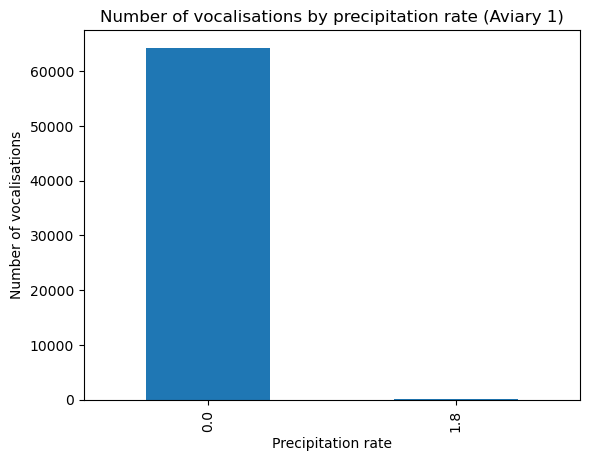

In [29]:
# Compare precipitation rate to the number of vocalisations in data set 1, because set 2 does not have any rain
df_1.groupby("precipRate")["Call_Presence"].sum().plot(kind="bar")
plt.title("Number of vocalisations by precipitation rate (Aviary 1)")
plt.xlabel("Precipitation rate")
plt.ylabel("Number of vocalisations")
plt.show()

In [4]:
# See effect of rain on vocalisations
# precipRate we dont know the measure, not explained in the README
"""
rainy_days = df[df["precipRate"] > 0.25] 
rainy_days_calls = rainy_days["fusion_model_prediction"].notnull().sum()

non_rainy_days = df[df["precipRate"] <= 0.25] 
non_rainy_days_calls = non_rainy_days["fusion_model_prediction"].notnull().sum()

print(f'Rainy days vocalisations: {rainy_days_calls/len(rainy_days)*100:.2f}%')
print(f'Non-rainy days vocalisations: {non_rainy_days_calls/len(non_rainy_days)*100:.2f}%')


df['rain'] = (df['precipRate'] > 0.25).astype(int)
contingency_table = pd.crosstab(df['rain'], df['Call_Presence'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(contingency_table)
print(f"Chi-squared: {chi2:.4f}, p-value: {p_value:.4f}") # Not sure this test is correct
"""

'\nrainy_days = df[df["precipRate"] > 0.25] \nrainy_days_calls = rainy_days["fusion_model_prediction"].notnull().sum()\n\nnon_rainy_days = df[df["precipRate"] <= 0.25] \nnon_rainy_days_calls = non_rainy_days["fusion_model_prediction"].notnull().sum()\n\nprint(f\'Rainy days vocalisations: {rainy_days_calls/len(rainy_days)*100:.2f}%\')\nprint(f\'Non-rainy days vocalisations: {non_rainy_days_calls/len(non_rainy_days)*100:.2f}%\')\n\n\ndf[\'rain\'] = (df[\'precipRate\'] > 0.25).astype(int)\ncontingency_table = pd.crosstab(df[\'rain\'], df[\'Call_Presence\'])\nchi2, p_value, dof, expected = chi2_contingency(contingency_table)\n\nprint(contingency_table)\nprint(f"Chi-squared: {chi2:.4f}, p-value: {p_value:.4f}") # Not sure this test is correct\n'

In [5]:
# Look at the impact of temperature on vocalisations
"""
print(f"Maximum temperature: {df['tempAve'].max()}, Minimum temperature: {df['tempAve'].min()}\n")

bins = [df['tempAve'].min(), 20, df['tempAve'].max()]
bins = [i for i in range(int(df['tempAve'].min()), int(df['tempAve'].max()) + 1, 5)]

df['temp_category'] = pd.cut(df['tempAve'], bins=bins)
counts = df.groupby('temp_category')['Call_Presence'].count()/len(df)

print(counts)
"""

'\nprint(f"Maximum temperature: {df[\'tempAve\'].max()}, Minimum temperature: {df[\'tempAve\'].min()}\n")\n\nbins = [df[\'tempAve\'].min(), 20, df[\'tempAve\'].max()]\nbins = [i for i in range(int(df[\'tempAve\'].min()), int(df[\'tempAve\'].max()) + 1, 5)]\n\ndf[\'temp_category\'] = pd.cut(df[\'tempAve\'], bins=bins)\ncounts = df.groupby(\'temp_category\')[\'Call_Presence\'].count()/len(df)\n\nprint(counts)\n'